# TabNet for King County House Price Prediction

- **Module:** IT2011 – Artificial Intelligence and Machine Learning
- **Task:** supervised regression – predict the sale `price` of a house from its features.
- **Model:** TabNet, a deep-learning model designed for tabular data.

## What is TabNet?

Ordinary neural networks (MLPs) feed every feature into every neuron. TabNet instead makes its prediction in a few **decision steps**. At each step an *attention mask* picks a small subset of the features to look at, a small network processes them, and the outputs of all steps are added up to give the prediction.

Three properties make it a reasonable choice for this dataset:

1. **It learns which features matter, row by row.** A waterfront mansion and a small inland flat can be priced using different features.
2. **It handles categorical columns with embeddings.** `zipcode` has 70 values; TabNet can learn a small vector per zipcode instead of needing 70 separate one-hot columns.
3. **It is interpretable.** The attention masks tell us which features were used, so we get feature importances without a separate tool.

An honest expectation to state up front: on a dataset of about 21,000 rows, gradient-boosted trees (LightGBM, CatBoost) usually match or beat deep tabular models. The value of this notebook to the group is a properly tuned deep-learning result to compare the tree models against.

## What this notebook does

| Section | Content |
|---|---|
| 1 | Setup and configuration |
| 2 | Load the datasets and check they line up |
| 3 | Build three versions of the features (three pre-processing varieties) |
| 4 | Train / validation / test split |
| 5 | Helper functions (target transform, metrics, model training) |
| 6 | Simple baselines |
| 7 | TabNet varieties with default hyperparameters |
| 8 | Hyperparameter tuning with Optuna |
| 9 | 5-fold cross-validation |
| 10 | Final model on the held-out test set |
| 11 | Interpretability |
| 12 | Save the model and results |
| 13 | Conclusions |

## 1. Setup and configuration

All imports and every setting that controls the run live in the next two cells, so there is one place to change things.

In [ ]:
# Google Colab does not come with TabNet or Optuna, so install whichever is missing
# (ipywidgets is only needed for the download buttons in Section 12).
# On a machine that already has them this cell does nothing.
import importlib.util
import subprocess
import sys

needed = {"pytorch-tabnet": "pytorch_tabnet", "optuna": "optuna", "ipywidgets": "ipywidgets"}   # pip name -> import name
missing = [pip_name for pip_name, module in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

In [ ]:
# --- Standard library ---
import contextlib      # temporarily silencing a library's printed output
import io              # an in-memory "file" to send that output to
import json            # saving settings/results as JSON
import os              # reading environment variables
import time            # timing how long training takes
import warnings        # silencing harmless library warnings
from dataclasses import dataclass   # a small class that just holds a few named values
from pathlib import Path

# Harmless notices that would otherwise clutter the output:
warnings.filterwarnings("ignore", message=".*IProgress not found.*")   # progress-bar widget not installed
warnings.filterwarnings("ignore", category=FutureWarning)              # torch.load notice when reloading the model

# --- Data handling and plotting ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FixedLocator, FuncFormatter, MaxNLocator, NullLocator
from IPython.display import Markdown, display

# --- scikit-learn: splitting, baselines, metrics ---
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score)
from sklearn.model_selection import (GroupKFold, GroupShuffleSplit, KFold, ShuffleSplit,
                                     train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- Deep learning: PyTorch and the TabNet implementation built on it ---
import torch
from pytorch_tabnet.callbacks import Callback
from pytorch_tabnet.pretraining import TabNetPretrainer
from pytorch_tabnet.tab_model import TabNetRegressor

# --- Hyperparameter tuning ---
import optuna

# pytorch-tabnet prints a warning every time early stopping restores the best weights;
# that is expected behaviour, so hide it to keep the output readable.
warnings.filterwarnings("ignore", category=UserWarning)
# Only show Optuna warnings/errors (it would otherwise print a line for every trial).
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# ----------------------------- Run settings -----------------------------

# FAST_RUN = True trains for only a few epochs so the whole notebook finishes in a
# couple of minutes. It is for checking that the code runs, NOT for real results.
# It can also be switched on from outside with the environment variable TABNET_FAST_RUN=1.
FAST_RUN = os.environ.get("TABNET_FAST_RUN", "0") == "1"

# GROUP_SPLIT = True keeps every sale of the same house (same `id`) on the same side
# of the train/validation split and of each cross-validation fold. Set to False to use
# ordinary random splits instead.
GROUP_SPLIT = True

SEED = 42                # one seed for every random step, so results are repeatable
VAL_SIZE = 0.15          # 15% of the training file is used as the validation set
N_FOLDS = 5              # k in k-fold cross-validation

MAX_EPOCHS = 5 if FAST_RUN else 200       # upper limit on training epochs
PATIENCE = 5 if FAST_RUN else 30          # stop if validation has not improved for this many epochs

N_TRIALS = 3 if FAST_RUN else 30          # number of hyperparameter combinations Optuna tries
TUNE_MAX_EPOCHS = 5 if FAST_RUN else 150  # slightly shorter training while tuning, to save time
TUNE_PATIENCE = 5 if FAST_RUN else 20

RUN_PRETRAIN_VARIANT = True               # whether to run the optional self-supervised variant (V6)
PRETRAIN_EPOCHS = 5 if FAST_RUN else 100

# The metric used whenever one model has to be chosen over another.
# RMSE is used because it is in dollars and ranks models the same way R² does.
SELECT_METRIC = "RMSE"

# ----------------------------- File locations -----------------------------
# All three CSVs are read straight from the group's GitHub repository, so the notebook runs
# on Google Colab (or any machine) without uploading files. These are plain strings, not
# Path objects, because Path would break the "https://" in a URL.
GITHUB_RAW = "https://raw.githubusercontent.com/IT25200308/2026-Y2-S1-MET-26/refs/heads/lochana/csvAccess"
DATA_TRAIN = f"{GITHUB_RAW}/results/outputs/final_train_processed_house_data.csv"   # the group's pre-processed training rows
DATA_TEST = f"{GITHUB_RAW}/results/outputs/final_test_processed_house_data.csv"     # the group's pre-processed test rows
DATA_RAW = f"{GITHUB_RAW}/data/raw/kc_house_data.csv"                               # the original Kaggle file

# How the group's pre-processing divided the raw rows into the two files above:
# train_test_split(test_size=0.20, random_state=42). The same call is repeated in Section 2
# to line the raw file up with the processed files, so these two must match it.
TEST_SIZE = 0.20         # share of the rows that is in the test file
UPSTREAM_SEED = 42       # random_state of that split
MODELS_DIR = Path("models")
RESULTS_DIR = Path("results")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# ----------------------------- Reproducibility -----------------------------
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use the GPU if PyTorch can see one, otherwise fall back to the CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))
print(f"FAST_RUN = {FAST_RUN} | GROUP_SPLIT = {GROUP_SPLIT}")

PyTorch 2.11.0+cu130 | device: cuda (Tesla T4)
FAST_RUN = False | GROUP_SPLIT = True


In [ ]:
# ----------------------------- Plot styling -----------------------------
# One consistent look for every chart: quiet grid and axes, and a small fixed colour set.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # series colours
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e1e0d9"  # text and grid colours
# A single-hue light-to-dark ramp, used for heatmaps where colour means "how much".
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", ["#fcfcfb", "#cde2fb", "#6da7ec", "#2a78d6", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "text.color": INK,
    "font.family": "sans-serif", "font.size": 9.5, "legend.frameon": False,
    "lines.linewidth": 2, "figure.dpi": 110,
})


def dollars(value):
    """Format a number as whole dollars, e.g. 123456.7 -> '$123,457'."""
    return f"${value:,.0f}"


def price_log_axis(axis):
    """Give a log-scaled price axis (in million $) plain, well-spaced tick labels."""
    axis.set_major_locator(FixedLocator([0.1, 0.2, 0.5, 1, 2, 5]))
    axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    axis.set_minor_locator(NullLocator())

## 2. Load and check the data

Three files are used:

* **`final_train_processed_house_data.csv`** and **`final_test_processed_house_data.csv`** – the group's pre-processed dataset. The group first split the raw rows into a training part (80%) and a test part (20%) and pre-processed them afterwards. In both files the zipcode is one-hot encoded (70 columns), most numeric columns are standardised, and `price` is in raw dollars. The training file is what the models learn from; the test file is the held-out test set.
* **`kc_house_data.csv`** – the original Kaggle file. The processed files no longer contain the house `id`, the sale `date` or a single `zipcode` column, so these are taken from here.

The two processed files are stacked into one table, training rows first, so that the rest of the notebook can refer to any row by its position. The group's split was made with `train_test_split(test_size=0.20, random_state=42)` on the raw rows; repeating it on the raw file puts the raw rows in the same order, so row *i* in one is row *i* in the other. The checks below **prove** that before anything relies on it.

In [ ]:
train_proc = pd.read_csv(DATA_TRAIN)   # processed training rows: features + price
test_proc = pd.read_csv(DATA_TEST)     # processed test rows: same columns
raw = pd.read_csv(DATA_RAW)            # original data: id, date, price + 18 raw features

assert list(train_proc.columns) == list(test_proc.columns), "The two processed files have different columns"

# One table for the whole notebook: training-file rows first, test-file rows after them.
# Rows 0 .. N_TRAIN_FILE-1 are the training file; the rest are the test file.
N_TRAIN_FILE = len(train_proc)
proc = pd.concat([train_proc, test_proc], ignore_index=True)

print(f"processed train: {train_proc.shape[0]:,} rows x {train_proc.shape[1]} columns")
print(f"processed test:  {test_proc.shape[0]:,} rows x {test_proc.shape[1]} columns")
print(f"raw:             {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"missing values -> processed: {int(proc.isna().sum().sum())}, raw: {int(raw.isna().sum().sum())}")

# The 70 one-hot zipcode columns, in sorted order (zipcode_98001 ... zipcode_98199).
ZIP_COLS = sorted(c for c in proc.columns if c.startswith("zipcode_"))
# Every other column except the target: the 22 numeric / engineered features.
NUM_COLS = [c for c in proc.columns if c not in ZIP_COLS and c != "price"]
print(f"{len(NUM_COLS)} numeric features, {len(ZIP_COLS)} zipcode one-hot columns, target = price")

processed train: 17,290 rows x 93 columns
processed test:  4,323 rows x 93 columns
raw:             21,613 rows x 21 columns
missing values -> processed: 0, raw: 0
22 numeric features, 70 zipcode one-hot columns, target = price


In [ ]:
# ----------------------------- Alignment checks -----------------------------
# Repeat the group's split on the raw row positions, then put the raw rows in the same
# order as `proc`: training-file rows first, test-file rows after them.
raw_train_pos, raw_test_pos = train_test_split(np.arange(len(raw)), test_size=TEST_SIZE,
                                               random_state=UPSTREAM_SEED)
raw = raw.iloc[np.concatenate([raw_train_pos, raw_test_pos])].reset_index(drop=True)

# 1) Same number of rows, in total and in each file.
assert len(proc) == len(raw), "The processed and raw data have different numbers of rows"
assert len(raw_train_pos) == N_TRAIN_FILE, "The training file does not have the expected number of rows"

# 2) The price is identical on every row -> the rows are in the same order.
assert np.allclose(proc["price"].to_numpy(), raw["price"].to_numpy()), "Prices differ: rows are not aligned"

# 3) Every row has exactly one zipcode column switched on.
assert (proc[ZIP_COLS].sum(axis=1) == 1).all(), "Some rows do not have exactly one zipcode set"

# 4) Turn the 70 one-hot columns back into ONE integer column: 0..69.
#    argmax returns the position of the column that holds the 1.
zip_idx = proc[ZIP_COLS].to_numpy().argmax(axis=1)                 # shape (n_rows,)
zip_from_onehot = np.array([int(c.split("_")[1]) for c in ZIP_COLS])[zip_idx]
#    ...and confirm it equals the zipcode stored in the raw file.
assert (zip_from_onehot == raw["zipcode"].to_numpy()).all(), "One-hot zipcode does not match the raw zipcode"

print("All alignment checks passed: the processed and raw data can be joined row by row.")

# The house id is used ONLY to split the data safely. It is never a model feature.
groups = raw["id"].to_numpy()
n_repeat = len(groups) - len(np.unique(groups))
print(f"{len(np.unique(groups)):,} unique houses; {n_repeat} rows are repeat sales of a house already in the data.")

# The target, in dollars, as a plain array.
y_all = proc["price"].to_numpy(dtype=np.float64)

All alignment checks passed: the processed and raw data can be joined row by row.
21,436 unique houses; 177 rows are repeat sales of a house already in the data.


### The target: `price`

House prices are *right-skewed*: most houses are in the low hundreds of thousands, with a long tail of very expensive ones. A neural network trained with squared error on raw dollars is dominated by that tail. Taking `log1p(price)` (the natural log of 1 + price) makes the distribution close to symmetric, which is far easier to learn.

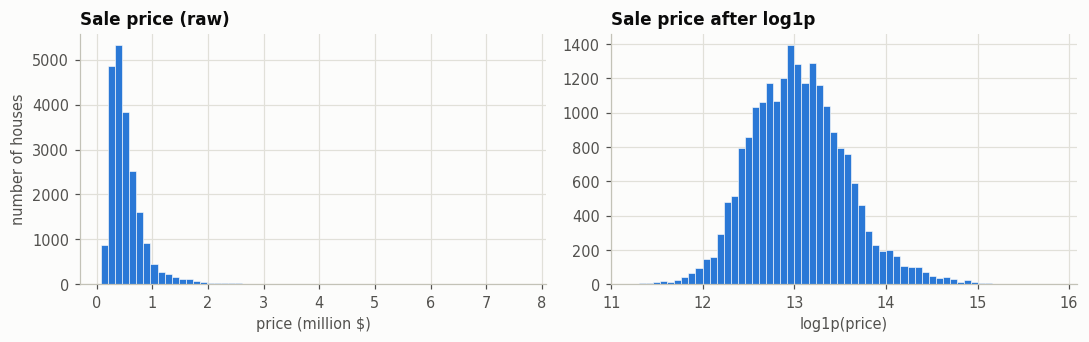

price: min $75,000, median $450,000, mean $540,088, max $7,700,000
skewness: raw 4.02 -> log1p 0.43


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

# Left: raw prices, in millions of dollars so the axis is readable.
axes[0].hist(y_all / 1e6, bins=60, color=BLUE, edgecolor="#fcfcfb", linewidth=0.4)
axes[0].set_title("Sale price (raw)")
axes[0].set_xlabel("price (million $)")
axes[0].set_ylabel("number of houses")

# Right: the same prices after the log transform.
axes[1].hist(np.log1p(y_all), bins=60, color=BLUE, edgecolor="#fcfcfb", linewidth=0.4)
axes[1].set_title("Sale price after log1p")
axes[1].set_xlabel("log1p(price)")

plt.tight_layout()
plt.show()

print(f"price: min {dollars(y_all.min())}, median {dollars(np.median(y_all))}, "
      f"mean {dollars(y_all.mean())}, max {dollars(y_all.max())}")
print(f"skewness: raw {pd.Series(y_all).skew():.2f} -> log1p {pd.Series(np.log1p(y_all)).skew():.2f}")

**Interpretation:** the left chart has almost all houses squeezed against the left edge with a long tail to the right. After `log1p` (right) the shape is close to a bell curve. A skewness near 0 means symmetric.

## 3. Feature sets (pre-processing varieties)

The assignment asks for the model to be evaluated with **different pre-processing**. Three versions of the features are built from the same rows:

| Name | What it contains | Why |
|---|---|---|
| `onehot` | The processed CSVs exactly as given: 22 numeric + 70 zipcode one-hot columns | The group's shared pre-processing, unchanged |
| `embedded` | The 22 processed numeric columns + **one** integer zipcode column | Lets TabNet learn an *embedding* (a small vector) per zipcode, instead of spreading its attention over 70 columns |
| `raw_rebuilt` | The same 22 features re-derived from the raw file + one integer zipcode column | Built independently of the group's pre-processing, as a cross-check that the processed files carry the same information as the raw data |

Every model is trained through a pipeline that standardises the numeric columns using the **training rows only** (Section 5.3). Standardising a column gives the same result whether or not it was linearly rescaled beforehand, so `raw_rebuilt` should score about the same as `embedded`.

In [ ]:
def build_onehot(proc):
    """Feature set 1: the processed CSVs exactly as given.

    Returns a dict with:
      X               - array, shape (n_rows, 92)
      feature_names   - column names, in the same order as the columns of X
      cat_idxs        - positions of categorical columns (none here)
      cat_dims        - number of categories for each categorical column (none here)
      zip_positions   - positions of the 70 zipcode columns (used for grouping and for plots)
      scale_positions - positions of the numeric columns that get standardised before training
    """
    names = NUM_COLS + ZIP_COLS
    return dict(
        X=proc[names].to_numpy(dtype=np.float64),
        feature_names=names,
        cat_idxs=[], cat_dims=[],
        zip_positions=list(range(len(NUM_COLS), len(names))),
        scale_positions=list(range(len(NUM_COLS))),     # the 22 numeric columns; the 0/1 zipcode columns are left alone
    )


def build_embedded(proc, zip_idx):
    """Feature set 2: processed numeric columns + ONE integer zipcode column (0..69).

    The integer column is declared categorical through cat_idxs / cat_dims, so TabNet
    looks each value up in an embedding table instead of treating it as a number.
    """
    X = np.column_stack([proc[NUM_COLS].to_numpy(dtype=np.float64), zip_idx])      # shape (n_rows, 23)
    return dict(
        X=X,
        feature_names=NUM_COLS + ["zipcode"],
        cat_idxs=[len(NUM_COLS)],      # the zipcode column is the last one (position 22)
        cat_dims=[len(ZIP_COLS)],      # it has 70 different values
        zip_positions=[],
        scale_positions=list(range(len(NUM_COLS))),     # scale the numeric columns, never the zipcode code
    )


def rebuild_numeric_from_raw(raw):
    """Re-create the 22 numeric features from the raw file WITHOUT any scaling.

    Every step here uses only the values on the row itself (no means or standard
    deviations over the dataset). Scaling is done later, inside the training pipeline,
    using training rows only.
    """
    out = pd.DataFrame(index=raw.index)

    # Columns that are used as they are.
    for col in ["bedrooms", "bathrooms", "floors", "waterfront", "view", "condition", "grade",
                "sqft_basement", "yr_built", "lat", "long", "sqft_living15"]:
        out[col] = raw[col].astype(float)

    # The date looks like '20141013T000000'; the first 8 characters are YYYYMMDD.
    sale_date = pd.to_datetime(raw["date"].str[:8], format="%Y%m%d")
    out["sale_year"] = sale_date.dt.year
    out["sale_month"] = sale_date.dt.month

    # Age of the house when it was sold (a few houses were sold before completion -> clip at 0).
    out["house_age"] = (out["sale_year"] - raw["yr_built"]).clip(lower=0)

    # yr_renovated is 0 when the house was never renovated. Six houses were renovated the year
    # AFTER they were sold; at the time of sale they were not renovated, so they count as 0
    # (this matches how the processed file defines the column).
    renovated = (raw["yr_renovated"] > 0) & (raw["yr_renovated"] <= out["sale_year"])
    out["has_renovation"] = renovated.astype(int)
    out["renovation_age"] = np.where(renovated, out["sale_year"] - raw["yr_renovated"], 0)

    # How much of the lot is covered by living space.
    out["living_lot_ratio"] = raw["sqft_living"] / raw["sqft_lot"]

    # Area columns are right-skewed, so use their logarithm (as the processed file does).
    for col in ["sqft_living", "sqft_lot", "sqft_above", "sqft_lot15"]:
        out[f"{col}_log"] = np.log1p(raw[col])

    return out[NUM_COLS]     # same column order as the processed files


def build_from_raw(raw, zip_idx):
    """Feature set 3: features rebuilt from the raw file + integer zipcode column."""
    rebuilt = rebuild_numeric_from_raw(raw)
    X = np.column_stack([rebuilt.to_numpy(dtype=np.float64), zip_idx])             # shape (n_rows, 23)
    return dict(
        X=X,
        feature_names=NUM_COLS + ["zipcode"],
        cat_idxs=[len(NUM_COLS)], cat_dims=[len(ZIP_COLS)],
        zip_positions=[],
        scale_positions=list(range(len(NUM_COLS))),
    )


FEATURE_SETS = {
    "onehot": build_onehot(proc),
    "embedded": build_embedded(proc, zip_idx),
    "raw_rebuilt": build_from_raw(raw, zip_idx),
}
for name, fs in FEATURE_SETS.items():
    print(f"{name:12s} X shape = {fs['X'].shape}, categorical columns = {fs['cat_idxs']}")

onehot       X shape = (21613, 92), categorical columns = []
embedded     X shape = (21613, 23), categorical columns = [22]
raw_rebuilt  X shape = (21613, 23), categorical columns = [22]


### Check: does the rebuilt feature set match the processed one?

If the upstream pre-processing only *rescaled* each column, then every rebuilt column should be perfectly correlated (correlation = 1.0) with the processed column of the same name. A lower value would mean the processed file did something more to that column (for example clipping outliers).

In [ ]:
rebuilt = rebuild_numeric_from_raw(raw)

check = pd.DataFrame({
    # Pearson correlation between the processed column and the column rebuilt from raw.
    "correlation": [np.corrcoef(proc[c], rebuilt[c])[0, 1] for c in NUM_COLS],
    # True when the two columns hold exactly the same numbers (i.e. the column was not scaled).
    "identical_values": [bool(np.allclose(proc[c], rebuilt[c])) for c in NUM_COLS],
    # Mean and standard deviation of the column in the processed training file:
    # ~0 and ~1 means it was standardised.
    "processed_mean": [train_proc[c].mean() for c in NUM_COLS],
    "processed_std": [train_proc[c].std() for c in NUM_COLS],
}, index=NUM_COLS)

display(check.style.format({"correlation": "{:.6f}", "processed_mean": "{:.3f}", "processed_std": "{:.3f}"}))
print(f"lowest correlation: {check['correlation'].min():.6f} ({check['correlation'].idxmin()})")
print(f"{int(check['identical_values'].sum())} columns are identical to the rebuilt ones (never scaled); "
      f"{int((~check['identical_values']).sum())} are rescaled copies.")

# The rebuilt features must carry exactly the same information as the processed ones,
# otherwise V4 and V5 would differ in more than just the scaling.
assert check["correlation"].min() > 0.999999, "A rebuilt column does not match its processed column"

,correlation,identical_values,processed_mean,processed_std
bedrooms,1.000000,False,-0.000,1.000
bathrooms,1.000000,False,-0.000,1.000
floors,1.000000,False,0.000,1.000
waterfront,1.000000,True,0.007,0.084
view,1.000000,True,0.233,0.762
condition,1.000000,True,3.408,0.652
grade,1.000000,True,7.654,1.170
sqft_basement,1.000000,False,-0.000,1.000
yr_built,1.000000,False,-0.000,1.000
lat,1.000000,False,-0.000,1.000


lowest correlation: 1.000000 (condition)
10 columns are identical to the rebuilt ones (never scaled); 12 are rescaled copies.


**Interpretation:** a correlation of 1.000000 means the processed column is just a shifted/rescaled copy of the rebuilt one. `identical_values = True` marks columns the upstream pipeline left unscaled. Columns with `processed_mean = 0` and `processed_std = 1` (measured on the training file) were standardised upstream. Because every correlation is 1, the `embedded` and `raw_rebuilt` feature sets differ *only* in that scaling. Ten columns (for example `sale_year`, with values 2014 and 2015) were never scaled at all, which matters in Section 5.3.

## 4. Train / validation / test split

The rows are divided into three parts:

* **Test (the group's test file, 20% of all rows)** – locked away until Section 10. It is used exactly once, to report the final result.
* **Validation (15% of the training file)** – used to decide when to stop training, to compare varieties, and to tune hyperparameters.
* **Train (the rest of the training file)** – what the model actually learns from.

**Why a *grouped* split?** 177 rows are a second (or third) sale of a house that already appears in the data. With an ordinary random split, the same house could be in both the training and the validation rows, and the validation score would then look better than it should. Splitting the training file by house `id` keeps all sales of one house together.

In [ ]:
def split_once(idx, test_size, seed):
    """Split an array of row positions into two parts.

    idx       - the row positions to split
    test_size - fraction that goes into the second part
    seed      - random seed

    With GROUP_SPLIT on, all rows of the same house id go to the same part.
    Returns (first_part, second_part) as arrays of row positions.
    """
    if GROUP_SPLIT:
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        a, b = next(splitter.split(idx, groups=groups[idx]))
    else:
        splitter = ShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        a, b = next(splitter.split(idx))
    return idx[a], idx[b]      # a and b are positions inside idx, so map them back


idx_trainval = np.arange(N_TRAIN_FILE)                            # every row of the training file
idx_test = np.arange(N_TRAIN_FILE, len(proc))                     # every row of the test file
idx_train, idx_val = split_once(idx_trainval, VAL_SIZE, SEED)     # 85% / 15% of the training file

print(f"train: {len(idx_train):,} rows | validation: {len(idx_val):,} rows | test: {len(idx_test):,} rows")

if GROUP_SPLIT:
    # Check: no house id may be in both the training and the validation rows.
    assert not (set(groups[idx_train]) & set(groups[idx_val])), "A house is in both train and validation"
    print("No house appears in both the training and the validation rows.")

train: 14,695 rows | validation: 2,595 rows | test: 4,323 rows
No house appears in both the training and the validation rows.


## 5. Helper functions

Everything below is used repeatedly in later sections, so it is written once here.

### 5.1 Target transform

The model is trained on a transformed target and its predictions are converted back to dollars before any metric is computed. The transform is: optional `log1p`, then standardise (subtract the mean, divide by the standard deviation). The mean and standard deviation are computed **from the training rows only**; validation and test prices are never used for them.

In [ ]:
class TargetTransformer:
    """Converts prices to the scale the network trains on, and back again."""

    def __init__(self, log=True):
        self.log = log            # True: use log1p(price); False: use the raw price

    def fit(self, y):
        """Learn the mean and standard deviation from TRAINING prices only."""
        z = np.log1p(y) if self.log else y
        self.mean_ = float(z.mean())
        self.std_ = float(z.std())
        # Remember the range of training targets (used as a safety limit in inverse()).
        self.min_, self.max_ = float(z.min()), float(z.max())
        return self

    def transform(self, y):
        """Dollars -> training scale. Returns shape (n, 1), which TabNetRegressor requires."""
        z = np.log1p(y) if self.log else y
        return ((z - self.mean_) / self.std_).reshape(-1, 1).astype(np.float32)

    def inverse(self, z):
        """Training scale -> dollars. Returns a flat array of shape (n,)."""
        z = np.asarray(z, dtype=np.float64).reshape(-1) * self.std_ + self.mean_
        if not self.log:
            return z
        # Safety limit: exp() turns one wild network output into an astronomically large price.
        # Predictions are therefore kept within the training price range plus one log-unit
        # (about 2.7x) either side. A well-trained model never comes near these limits.
        z = np.clip(z, self.min_ - 1.0, self.max_ + 1.0)
        return np.expm1(z)                         # expm1 undoes log1p

### 5.2 Metrics

The four metrics, all computed **in dollars**:

| Metric | Meaning | Why it is useful here |
|---|---|---|
| **MAE** | Average absolute error in dollars | Easy to explain: "on average we are off by $X" |
| **MAPE** | Average absolute error as a % of the true price | Treats cheap and expensive houses equally |
| **RMSE** | Square root of the average squared error | Punishes large mistakes more than MAE does |
| **R²** | Share of the variation in price that the model explains | 1.0 is perfect, 0 is no better than predicting the average |

Accuracy, F1 and confusion matrices are classification metrics and do not apply to a regression problem.

In [ ]:
def evaluate(y_true, y_pred):
    """Return the four regression metrics for predictions in dollars."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,   # as a percentage
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


# Number formats used whenever a metrics table is displayed.
METRIC_FORMAT = {"MAE": "${:,.0f}", "MAPE": "{:.2f}%", "RMSE": "${:,.0f}", "R2": "{:.4f}"}

### 5.3 Input scaling (a pipeline step)

Before training, each numeric column is standardised: subtract its mean and divide by its standard deviation, both computed **from the training rows only**. Zipcode columns are left as they are.

Why this is needed even though TabNet has a batch-normalisation layer on its input: that layer learns the column means gradually, as a running average. A column such as `sale_year` has a mean of about 2014 but only varies by ±1, so until the running average has converged (dozens of epochs) the network sees wildly wrong values whenever it is *evaluated*. The validation score is then meaningless for the first part of training, and early stopping can halt on a useless model. This was observed in an earlier run of this notebook: one cross-validation fold stopped at epoch 2 with an R² of −250. Standardising the inputs first removes the problem. Variety V7 in Section 7 switches the step off to show the effect.

In [ ]:
class InputScaler:
    """Standardises the numeric feature columns using statistics from the training rows only."""

    def __init__(self, positions, enabled=True):
        self.positions = positions    # which columns to scale
        self.enabled = enabled        # False = pass the data through unchanged (used by the V7 ablation)

    def fit(self, X_train):
        """Learn each numeric column's mean and standard deviation from the TRAINING rows."""
        self.mean_ = X_train[:, self.positions].mean(axis=0)
        std = X_train[:, self.positions].std(axis=0)
        self.std_ = np.where(std == 0, 1.0, std)      # a constant column would give 0; avoid dividing by it
        return self

    def transform(self, X):
        """Return a float32 copy of X with the numeric columns standardised."""
        X = np.array(X, dtype=np.float64)             # copy, so the original array is never changed
        if self.enabled:
            X[:, self.positions] = (X[:, self.positions] - self.mean_) / self.std_
        return X.astype(np.float32)                   # PyTorch works in float32

### 5.4 Building and training a TabNet model

`DEFAULT_PARAMS` holds the starting hyperparameters. Each one is explained in the comments. Section 8 searches for better values.

`fit_tabnet` runs the whole pipeline – scale the inputs, transform the target, train the network – and returns a `FittedTabNet` object that keeps the three fitted pieces together, so predictions always go through the same steps in the same order.

In [ ]:
DEFAULT_PARAMS = dict(
    n_d=16,                 # width of the "decision" output of each step (what feeds the prediction)
    n_a=16,                 # width of the "attention" output of each step (what chooses features for the next step)
                            #   bigger n_d / n_a = more capacity, but easier to overfit. Usually kept equal.
    n_steps=4,              # number of decision steps; each step can look at a different subset of features
    gamma=1.3,              # how freely a feature can be re-used in later steps:
                            #   1.0 = each feature used in one step only, larger = re-use allowed
    n_independent=2,        # layers in each step that are specific to that step
    n_shared=2,             # layers in each step that are shared between all steps
    lambda_sparse=1e-4,     # strength of the penalty that pushes each step to use only a FEW features
    momentum=0.02,          # momentum of the batch-normalisation layers (how fast their running stats update)
    mask_type="sparsemax",  # how the attention mask is made: "sparsemax" (very sparse) or "entmax" (softer)
    cat_emb_dim=8,          # length of the vector learned for each zipcode (only used with an integer zipcode column)
    lr=2e-2,                # learning rate of the Adam optimiser
    batch_size=1024,        # rows per training step
    virtual_batch_size=128, # "ghost" batch size: batch-norm statistics are computed on chunks of this size
                            #   inside each batch, which adds a little noise and helps generalisation
)


def network_kwargs(p, fs, use_groups):
    """Arguments shared by TabNetRegressor and TabNetPretrainer.

    p          - hyperparameter dict (same keys as DEFAULT_PARAMS)
    fs         - a feature-set dict from FEATURE_SETS
    use_groups - True to make the 70 one-hot zipcode columns share ONE attention weight
    """
    return dict(
        n_d=p["n_d"], n_a=p["n_a"], n_steps=p["n_steps"], gamma=p["gamma"],
        n_independent=p["n_independent"], n_shared=p["n_shared"],
        lambda_sparse=p["lambda_sparse"], momentum=p["momentum"], mask_type=p["mask_type"],
        # Which columns are categorical and how many categories each has.
        cat_idxs=fs["cat_idxs"], cat_dims=fs["cat_dims"],
        cat_emb_dim=p["cat_emb_dim"] if fs["cat_idxs"] else 1,
        # grouped_features: columns in the same group are selected (or ignored) together.
        grouped_features=[fs["zip_positions"]] if use_groups else [],
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=p["lr"]),
        # Learning-rate schedule: multiply the learning rate by 0.8 every 20 epochs,
        # so training takes big steps early and small, careful steps later.
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params=dict(step_size=20, gamma=0.8),
        seed=SEED,
        verbose=0,              # no per-epoch printing
        device_name=DEVICE,
    )


@dataclass
class FittedTabNet:
    """A trained pipeline: input scaler -> TabNet network -> target transform."""
    model: TabNetRegressor         # the trained network
    scaler: InputScaler            # how the inputs were scaled
    tt: TargetTransformer          # how the target was transformed

    def predict_dollars(self, X):
        """Predict prices in dollars for rows of an (unscaled) feature array."""
        return self.tt.inverse(self.model.predict(self.scaler.transform(X)))


def fit_tabnet(fs, idx_tr, idx_stop, params=None, log_target=True, use_groups=False, scale_inputs=True,
               max_epochs=MAX_EPOCHS, patience=PATIENCE, pretrainer=None, callbacks=None):
    """Train one TabNet pipeline.

    fs           - feature-set dict (which version of X to use)
    idx_tr       - row positions to train on
    idx_stop     - row positions used for early stopping (never trained on)
    params       - hyperparameters that override DEFAULT_PARAMS
    log_target   - True to train on log1p(price), False to train on raw price
    use_groups   - True to tie the one-hot zipcode columns into one attention group
    scale_inputs - True to standardise the numeric columns (train-only statistics)
    pretrainer   - an already-fitted TabNetPretrainer to start from (optional)
    callbacks    - extra pytorch-tabnet callbacks (used by Optuna for pruning)

    Returns a FittedTabNet.
    """
    p = {**DEFAULT_PARAMS, **(params or {})}

    # Fit the input scaler and the target transform on the TRAINING rows only (idx_stop is not used for this).
    scaler = InputScaler(fs["scale_positions"], enabled=scale_inputs).fit(fs["X"][idx_tr])
    tt = TargetTransformer(log=log_target).fit(y_all[idx_tr])

    model = TabNetRegressor(**network_kwargs(p, fs, use_groups))
    # pytorch-tabnet prints a "Stop training..." line at the end of every fit even with verbose=0.
    # redirect_stdout swallows it; the best epoch is reported by our own print statements instead.
    with contextlib.redirect_stdout(io.StringIO()):
        model.fit(
            X_train=scaler.transform(fs["X"][idx_tr]), y_train=tt.transform(y_all[idx_tr]),   # y shape (n, 1)
            eval_set=[(scaler.transform(fs["X"][idx_stop]), tt.transform(y_all[idx_stop]))],
            eval_name=["val"],
            eval_metric=["rmse"],          # monitored each epoch; early stopping watches this
            max_epochs=max_epochs,
            patience=patience,             # stop after this many epochs without improvement,
                                           #   then restore the weights from the best epoch
            batch_size=p["batch_size"],
            virtual_batch_size=p["virtual_batch_size"],
            num_workers=0,                 # load data in the main process (most reliable on Windows)
            drop_last=True,                # drop the final incomplete batch so batch-norm never sees a tiny batch
            from_unsupervised=pretrainer,
            callbacks=callbacks or [],
        )
    return FittedTabNet(model=model, scaler=scaler, tt=tt)

## 6. Baselines

Two very simple models are evaluated first, on the same validation rows:

* **Dummy** – always predicts the median training price. Its R² should be about 0. If it is not, the metric code is wrong.
* **Ridge regression** – a regularised linear model on the one-hot feature set with the log target. It gives a floor that a deep model has to clearly beat to be worth its complexity.

In [ ]:
results = []     # every result in the notebook is appended here and saved to CSV at the end

X_onehot = FEATURE_SETS["onehot"]["X"]
y_train, y_val, y_test = y_all[idx_train], y_all[idx_val], y_all[idx_test]

# --- Dummy: always predict the median of the training prices ---
dummy = DummyRegressor(strategy="median").fit(X_onehot[idx_train], y_train)
m = evaluate(y_val, dummy.predict(X_onehot[idx_val]))
results.append(dict(stage="baseline", model="Dummy (median)", evaluated_on="validation", **m))

# --- Ridge: linear model on the log target ---
tt_ridge = TargetTransformer(log=True).fit(y_train)
# StandardScaler is inside the pipeline, so it is fitted on the training rows only.
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge.fit(X_onehot[idx_train], tt_ridge.transform(y_train).ravel())
m = evaluate(y_val, tt_ridge.inverse(ridge.predict(X_onehot[idx_val])))
results.append(dict(stage="baseline", model="Ridge (log target)", evaluated_on="validation", **m))

baseline_df = pd.DataFrame(results).set_index("model")[["MAE", "MAPE", "RMSE", "R2"]]
display(baseline_df.style.format(METRIC_FORMAT))

,MAE,MAPE,RMSE,R2
model,,,,
Dummy (median),"$216,041",41.95%,"$353,577",-0.0606
Ridge (log target),"$71,290",13.32%,"$123,425",0.8708


## 7. TabNet varieties (default hyperparameters)

Each variety changes **one thing** about the pre-processing while keeping the hyperparameters fixed, so differences in the scores can be attributed to that change.

| Variety | Features | Target | What it tests |
|---|---|---|---|
| **V1** | one-hot zipcode | raw price | The data as given, no target transform |
| **V2** | one-hot zipcode | log1p price | Effect of the log target |
| **V3** | one-hot zipcode, 70 columns tied into one attention group | log1p price | Does treating zipcode as one feature for attention help? |
| **V4** | processed numerics + zipcode embedding | log1p price | Does a learned zipcode embedding help? |
| **V5** | rebuilt from raw + zipcode embedding | log1p price | Cross-check of V4 with features built straight from the raw file – expected to match it |
| **V6** | best of V2–V5 + self-supervised pre-training | log1p price | Does pre-training on the features alone help? |
| **V7** | best of V2–V5 **without** the input-scaling step | log1p price | Is the scaling step from Section 5.3 really needed? |

All varieties are scored on the **validation** set. The test set is still untouched.

In [ ]:
# Each entry says which feature set and which options a variety uses.
VARIANTS = {
    "V1 one-hot, raw target":     dict(fs="onehot",      log_target=False, use_groups=False),
    "V2 one-hot, log target":     dict(fs="onehot",      log_target=True,  use_groups=False),
    "V3 one-hot grouped, log":    dict(fs="onehot",      log_target=True,  use_groups=True),
    "V4 zip embedding, log":      dict(fs="embedded",    log_target=True,  use_groups=False),
    "V5 raw rebuilt + emb, log":  dict(fs="raw_rebuilt", log_target=True,  use_groups=False),
}

fitted = {}      # keeps each trained model so its training history can be plotted

for name, cfg in VARIANTS.items():
    start = time.time()
    fit = fit_tabnet(FEATURE_SETS[cfg["fs"]], idx_train, idx_val,
                     log_target=cfg["log_target"], use_groups=cfg["use_groups"])
    # Score in dollars on the validation rows.
    m = evaluate(y_val, fit.predict_dollars(FEATURE_SETS[cfg["fs"]]["X"][idx_val]))
    fitted[name] = fit.model
    results.append(dict(stage="variant", model=name, evaluated_on="validation",
                        best_epoch=fit.model.best_epoch, seconds=round(time.time() - start, 1), **m))
    print(f"{name:28s} RMSE {dollars(m['RMSE']):>10s} | R2 {m['R2']:.4f} | "
          f"best epoch {fit.model.best_epoch:3d} | {time.time() - start:5.0f}s")

V1 one-hot, raw target       RMSE   $129,541 | R2 0.8576 | best epoch  80 |   105s
V2 one-hot, log target       RMSE   $120,037 | R2 0.8778 | best epoch 156 |   150s
V3 one-hot grouped, log      RMSE   $122,635 | R2 0.8724 | best epoch 181 |   160s
V4 zip embedding, log        RMSE   $120,792 | R2 0.8762 | best epoch 124 |   138s
V5 raw rebuilt + emb, log    RMSE   $120,792 | R2 0.8762 | best epoch 124 |   128s


### V6 and V7: two add-ons to the best variety

**V6 – self-supervised pre-training.** TabNet can be **pre-trained without labels**: random cells of the feature table are hidden and the network learns to fill them in. The idea is that it learns how the features relate to each other before it ever sees a price. The pre-trained weights are then used as the starting point for the regressor.

Pre-training is applied on top of whichever of V2–V5 scored best, and uses the training rows only.

**V7 – no input scaling.** The same best variety trained with the scaling step from Section 5.3 switched off, to show what that step contributes.

In [ ]:
variant_df = (pd.DataFrame([r for r in results if r["stage"] == "variant"])
              .set_index("model"))

# The best variety that trains on the log target (V2-V5) is the base for pre-training.
log_variants = [n for n, c in VARIANTS.items() if c["log_target"]]
pretrain_base = variant_df.loc[log_variants, SELECT_METRIC].idxmin()

if RUN_PRETRAIN_VARIANT:
    cfg = VARIANTS[pretrain_base]
    fs = FEATURE_SETS[cfg["fs"]]
    start = time.time()

    # Step 1: unsupervised pre-training. Note there is no y here - only the (scaled) features.
    # The scaler is fitted on the same training rows that fit_tabnet uses, so both steps see identical inputs.
    pre_scaler = InputScaler(fs["scale_positions"]).fit(fs["X"][idx_train])
    pretrainer = TabNetPretrainer(**network_kwargs(DEFAULT_PARAMS, fs, cfg["use_groups"]))
    with contextlib.redirect_stdout(io.StringIO()):       # hide the library's "Stop training..." line
        pretrainer.fit(
            X_train=pre_scaler.transform(fs["X"][idx_train]),
            eval_set=[pre_scaler.transform(fs["X"][idx_val])],
            pretraining_ratio=0.5,         # hide 50% of the cells and learn to reconstruct them
            max_epochs=PRETRAIN_EPOCHS, patience=PATIENCE,
            batch_size=DEFAULT_PARAMS["batch_size"], virtual_batch_size=DEFAULT_PARAMS["virtual_batch_size"],
            num_workers=0, drop_last=True,
        )

    # Step 2: normal supervised training, starting from the pre-trained weights.
    fit = fit_tabnet(fs, idx_train, idx_val, log_target=True,
                     use_groups=cfg["use_groups"], pretrainer=pretrainer)
    m = evaluate(y_val, fit.predict_dollars(fs["X"][idx_val]))
    V6_NAME = f"V6 pre-trained ({pretrain_base.split()[0]} base)"
    fitted[V6_NAME] = fit.model
    results.append(dict(stage="variant", model=V6_NAME, evaluated_on="validation",
                        best_epoch=fit.model.best_epoch, seconds=round(time.time() - start, 1), **m))
    print(f"{V6_NAME:28s} RMSE {dollars(m['RMSE']):>10s} | R2 {m['R2']:.4f} | "
          f"best epoch {fit.model.best_epoch:3d} | {time.time() - start:5.0f}s")

# --- V7: the same base variety with the input-scaling step switched off ---
cfg = VARIANTS[pretrain_base]
fs = FEATURE_SETS[cfg["fs"]]
start = time.time()
fit = fit_tabnet(fs, idx_train, idx_val, log_target=True, use_groups=cfg["use_groups"], scale_inputs=False)
m = evaluate(y_val, fit.predict_dollars(fs["X"][idx_val]))
V7_NAME = f"V7 no input scaling ({pretrain_base.split()[0]} base)"
fitted[V7_NAME] = fit.model
results.append(dict(stage="variant", model=V7_NAME, evaluated_on="validation",
                    best_epoch=fit.model.best_epoch, seconds=round(time.time() - start, 1), **m))
print(f"{V7_NAME:28s} RMSE {dollars(m['RMSE']):>10s} | R2 {m['R2']:.4f} | "
      f"best epoch {fit.model.best_epoch:3d} | {time.time() - start:5.0f}s")

V6 pre-trained (V2 base)     RMSE   $110,233 | R2 0.8969 | best epoch  92 |   162s
V7 no input scaling (V2 base) RMSE   $129,343 | R2 0.8581 | best epoch  80 |    91s


,MAE,MAPE,RMSE,R2,best_epoch,seconds
model,,,,,,
V6 pre-trained (V2 base),"$66,263",12.64%,"$110,233",0.8969,92,162
"V2 one-hot, log target","$67,094",12.36%,"$120,037",0.8778,156,150
"V4 zip embedding, log","$68,341",12.75%,"$120,792",0.8762,124,138
"V5 raw rebuilt + emb, log","$68,341",12.75%,"$120,792",0.8762,124,128
"V3 one-hot grouped, log","$68,765",12.64%,"$122,635",0.8724,181,160
Ridge (log target),"$71,290",13.32%,"$123,425",0.8708,-,-
V7 no input scaling (V2 base),"$71,513",12.99%,"$129,343",0.8581,80,91
"V1 one-hot, raw target","$78,596",15.43%,"$129,541",0.8576,80,105
Dummy (median),"$216,041",41.95%,"$353,577",-0.0606,-,-


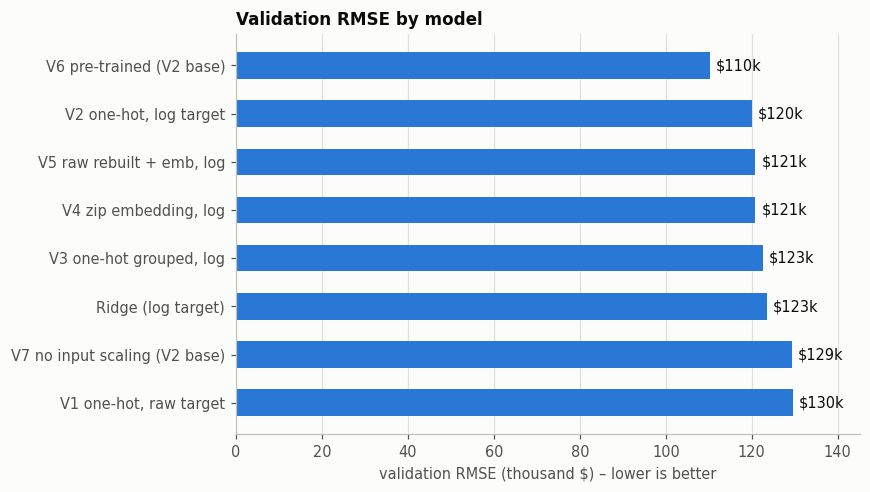

In [ ]:
# One table: baselines and all TabNet varieties, best RMSE first.
compare_df = (pd.DataFrame([r for r in results if r["stage"] in ("baseline", "variant")])
              .set_index("model")[["MAE", "MAPE", "RMSE", "R2", "best_epoch", "seconds"]]
              .sort_values("RMSE"))
display(compare_df.style.format({**METRIC_FORMAT, "best_epoch": "{:.0f}", "seconds": "{:.0f}"}, na_rep="-"))

# Horizontal bar chart of validation RMSE (the dummy baseline is left out: it would dwarf the rest).
plot_df = compare_df.drop(index="Dummy (median)").sort_values("RMSE", ascending=False)
fig, ax = plt.subplots(figsize=(8, 0.42 * len(plot_df) + 1.2))
bars = ax.barh(plot_df.index, plot_df["RMSE"] / 1000, color=BLUE, height=0.55)
ax.bar_label(bars, labels=[f"${v/1000:,.0f}k" for v in plot_df["RMSE"]], padding=4, color=INK)
ax.set_xlabel("validation RMSE (thousand $) – lower is better")
ax.set_title("Validation RMSE by model")
ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

**Interpretation:** each row is one model scored on the same validation rows. Lower MAE / MAPE / RMSE is better; higher R² is better. `best_epoch` is the epoch whose weights were kept by early stopping. Compare V1 with V2 for the effect of the log target, V2 with V3/V4 for the effect of how zipcode is represented, V4 with V5 for the effect of the upstream scaling, and V7 with its base for the effect of the input-scaling step. Each variety is a single training run, so differences of a few thousand dollars between two rows are within run-to-run noise.

### Training curves

For each variety, the chart shows the training error and the validation error after every epoch (both as RMSE on the standardised target, so lower is better). A validation line that flattens or rises while the training line keeps falling is the sign of overfitting – that is the point where early stopping steps in. If a line is missing from a panel, it is off the top of the chart (an RMSE above 1.2 means worse than always predicting the average).

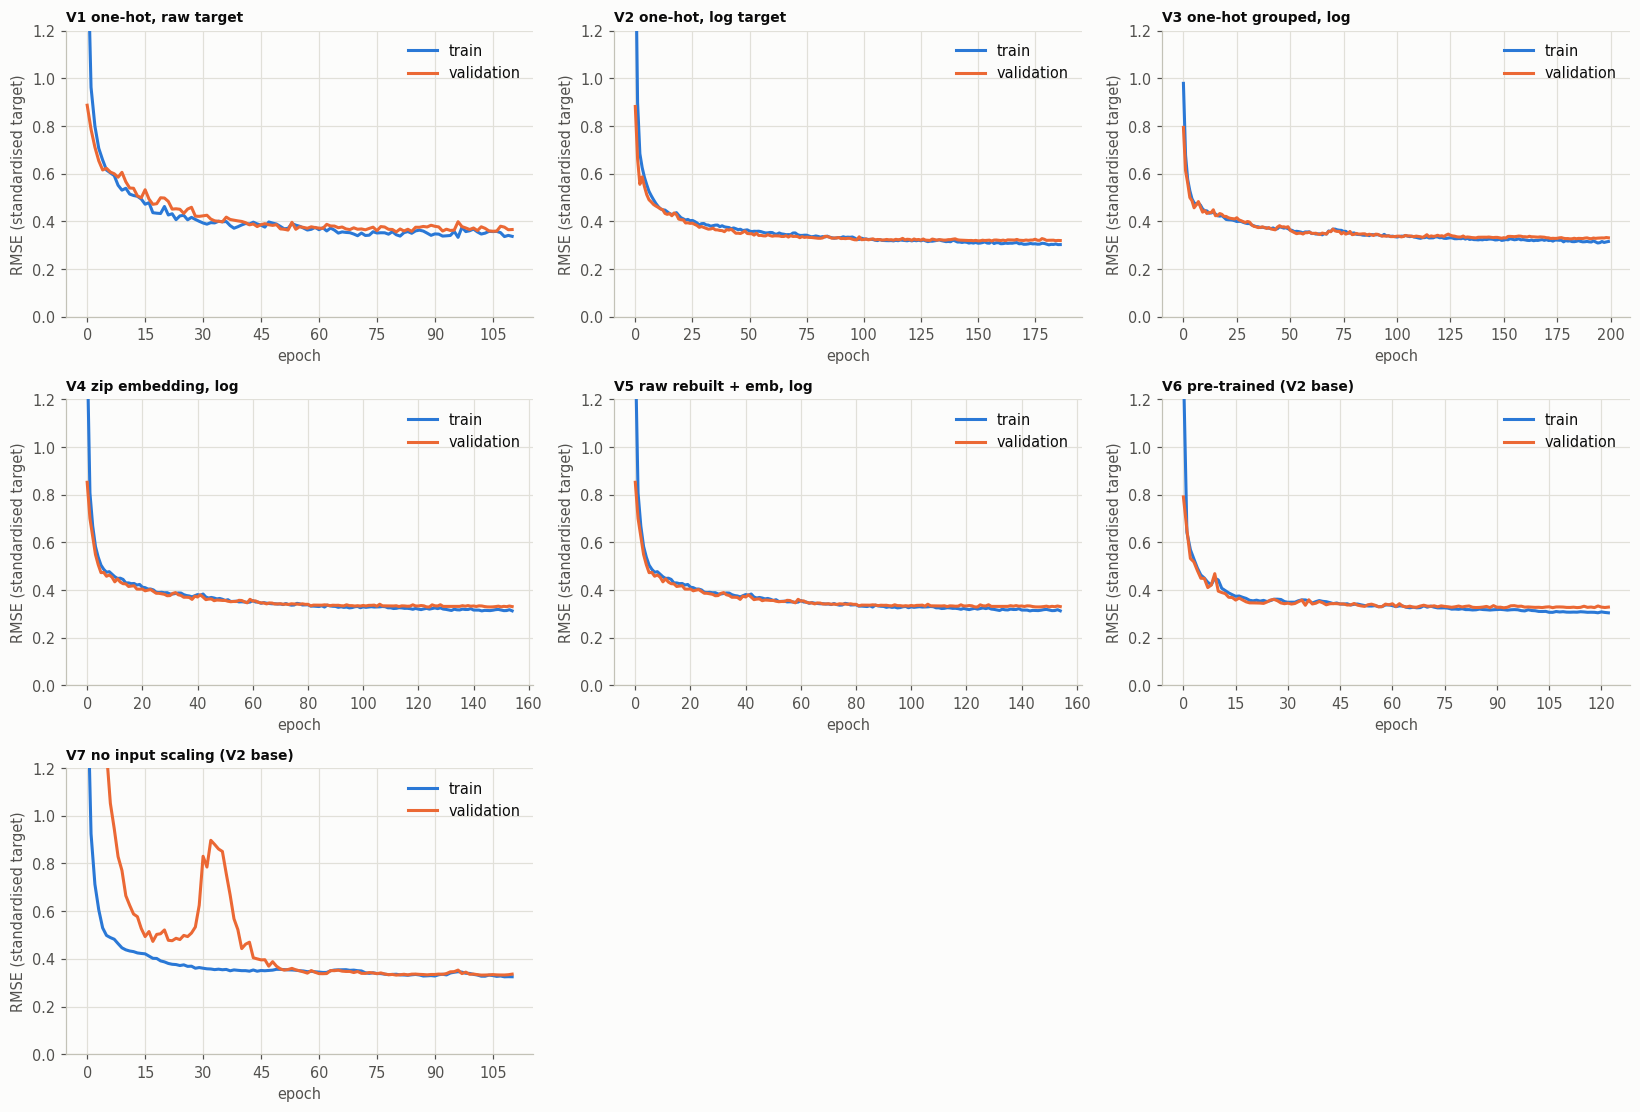

<IPython.core.display.Javascript object>

In [ ]:
names = list(fitted)
n_cols = 3
n_rows = int(np.ceil(len(names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.4 * n_rows), squeeze=False)

for ax, name in zip(axes.ravel(), names):
    hist = fitted[name].history
    # history["loss"] is the training MSE (plus the small sparsity penalty); sqrt makes it an RMSE.
    ax.plot(np.sqrt(np.clip(hist["loss"], 0, None)), color=BLUE, label="train")
    ax.plot(hist["val_rmse"], color=ORANGE, label="validation")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("epoch")
    ax.set_ylabel("RMSE (standardised target)")
    ax.set_ylim(0, 1.2)      # same scale on every panel so they can be compared
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(loc="upper right")

for ax in axes.ravel()[len(names):]:     # hide unused panels
    ax.set_visible(False)

plt.tight_layout()
plt.show()

from google.colab import output
output.no_vertical_scroll()

## 8. Hyperparameter tuning with Optuna

**Method:** Optuna runs a number of *trials*. In each trial it picks a set of hyperparameters, a model is trained with them, and the validation error is reported back. Optuna's default sampler (TPE, a Bayesian method) uses the results so far to pick more promising values next, so it needs far fewer trials than a full grid search (`GridSearchCV`) over the same ranges.

**Pruning:** After every epoch the validation error is reported to Optuna. If a trial is clearly worse than the median of earlier trials at the same epoch, it is stopped early to save time.

**What is tuned:** The pre-processing is fixed to the best variety from Section 7 (V1–V5). The objective is the validation RMSE on the transformed target at the best epoch.

In [ ]:
# The best base variety (V1-V5) is the one that gets tuned.
best_variant = variant_df.loc[list(VARIANTS), SELECT_METRIC].idxmin()
best_cfg = VARIANTS[best_variant]
best_fs = FEATURE_SETS[best_cfg["fs"]]
print(f"Tuning variety: {best_variant}  (feature set '{best_cfg['fs']}', log target = {best_cfg['log_target']})")


class OptunaPruningCallback(Callback):
    """Reports the validation RMSE to Optuna after every epoch so weak trials can be stopped early."""

    def __init__(self, trial):
        super().__init__()
        self.trial = trial

    def on_epoch_end(self, epoch, logs=None):
        self.trial.report(logs["val_rmse"], step=epoch)   # tell Optuna how this trial is doing
        if self.trial.should_prune():                     # Optuna says: not worth continuing
            raise optuna.TrialPruned()


def suggest_params(trial):
    """Ask Optuna for one set of hyperparameters. The ranges are explained line by line."""
    n_da = trial.suggest_categorical("n_da", [8, 16, 24, 32, 64])   # the TabNet paper recommends 8-64
    params = dict(
        n_d=n_da, n_a=n_da,                                         # kept equal, as the paper recommends
        n_steps=trial.suggest_int("n_steps", 3, 7),                 # paper range 3-10; more steps overfit small data
        gamma=trial.suggest_float("gamma", 1.0, 2.0),               # paper range 1.0-2.0
        n_independent=trial.suggest_int("n_independent", 1, 3),     # 1-3 layers is enough for ~20k rows
        n_shared=trial.suggest_int("n_shared", 1, 3),
        lambda_sparse=trial.suggest_float("lambda_sparse", 1e-6, 1e-3, log=True),  # log scale: spans 3 orders of magnitude
        lr=trial.suggest_float("lr", 5e-3, 3e-2, log=True),         # around the library default of 2e-2
        momentum=trial.suggest_float("momentum", 0.02, 0.3),        # library default 0.02, paper goes up to 0.4
        mask_type=trial.suggest_categorical("mask_type", ["sparsemax", "entmax"]),
        batch_size=trial.suggest_categorical("batch_size", [512, 1024]),  # ~1-7% of the training rows
    )
    if best_fs["cat_idxs"]:                                         # only when zipcode is an embedded column
        params["cat_emb_dim"] = trial.suggest_categorical("cat_emb_dim", [4, 8, 16])
    return params


def objective(trial):
    """Train one model with the suggested hyperparameters and return its best validation RMSE."""
    params = suggest_params(trial)
    trial.set_user_attr("params", params)                 # remember the full dict for later
    fit = fit_tabnet(best_fs, idx_train, idx_val, params=params,
                     log_target=best_cfg["log_target"], use_groups=best_cfg["use_groups"],
                     max_epochs=TUNE_MAX_EPOCHS, patience=TUNE_PATIENCE,
                     callbacks=[OptunaPruningCallback(trial)])
    trial.set_user_attr("best_epoch", int(fit.model.best_epoch))
    return float(fit.model.best_cost)                     # validation RMSE at the best epoch


study = optuna.create_study(
    direction="minimize",                                 # lower RMSE is better
    sampler=optuna.samplers.TPESampler(seed=SEED),        # seeded so the search is repeatable
    # Do not prune during the first 5 trials or the first 20 epochs of any trial.
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
)

start = time.time()
study.optimize(objective, n_trials=N_TRIALS)
print(f"{len(study.trials)} trials in {(time.time() - start) / 60:.1f} minutes")
print(f"best trial: #{study.best_trial.number} with validation RMSE {study.best_value:.4f} (transformed target)")

tuned_params = study.best_trial.user_attrs["params"]

# Side by side: the value every earlier model was trained with (DEFAULT_PARAMS) and the value Optuna chose.
show = lambda x: f"{x:.4g}" if isinstance(x, float) else str(x)     # short form for long decimals
param_tbl = pd.DataFrame({
    "Old Hyperparameter": [show(DEFAULT_PARAMS[k]) for k in tuned_params],
    "->": "→",
    "New Hyperparameter": [show(x) for x in tuned_params.values()],
}, index=pd.Index(list(tuned_params), name="Parameter name"))
display(Markdown("**Best hyperparameters**\n\n" + param_tbl.to_markdown(colalign=("left", "right", "center", "left"))))

Tuning variety: V2 one-hot, log target  (feature set 'onehot', log target = True)
30 trials in 25.9 minutes
best trial: #22 with validation RMSE 0.3200 (transformed target)


**Best hyperparameters**

| Parameter name   |   Old Hyperparameter |  ->  | New Hyperparameter   |
|:-----------------|---------------------:|:----:|:---------------------|
| n_d              |                   16 |  →   | 32                   |
| n_a              |                   16 |  →   | 32                   |
| n_steps          |                    4 |  →   | 3                    |
| gamma            |                  1.3 |  →   | 1.659                |
| n_independent    |                    2 |  →   | 2                    |
| n_shared         |                    2 |  →   | 3                    |
| lambda_sparse    |               0.0001 |  →   | 0.0005997            |
| lr               |                 0.02 |  →   | 0.008007             |
| momentum         |                 0.02 |  →   | 0.08895              |
| mask_type        |            sparsemax |  →   | entmax               |
| batch_size       |                 1024 |  →   | 1024                 |

In [ ]:
# Every trial: its hyperparameters, its score and whether it completed or was pruned.
trials_df = study.trials_dataframe(attrs=("number", "value", "state", "params", "duration"))
trials_df.columns = [c.replace("params_", "") for c in trials_df.columns]
trials_df["duration"] = trials_df["duration"].dt.total_seconds().round(0)
trials_df = trials_df.rename(columns={"value": "val_rmse", "duration": "seconds"})
trials_df.to_csv(RESULTS_DIR / "tabnet_optuna_trials.csv", index=False)

n_complete = int((trials_df["state"] == "COMPLETE").sum())
n_pruned = int((trials_df["state"] == "PRUNED").sum())
print(f"{n_complete} trials completed, {n_pruned} pruned. Ten best trials:")
display(trials_df.sort_values("val_rmse").head(10).style.format(precision=4))

13 trials completed, 17 pruned. Ten best trials:


,number,val_rmse,state,batch_size,gamma,lambda_sparse,lr,mask_type,momentum,n_da,n_independent,n_shared,n_steps,seconds
22,22,0.3200,COMPLETE,1024,1.6587,0.0006,0.0080,entmax,0.0890,32,2,3,3,64.0000
7,7,0.3245,COMPLETE,1024,1.8926,0.0005,0.0088,entmax,0.0508,8,2,3,3,116.0000
11,11,0.3255,COMPLETE,1024,1.6380,0.0002,0.0059,entmax,0.0500,32,2,3,3,62.0000
27,27,0.3270,COMPLETE,1024,1.5829,0.0000,0.0078,entmax,0.0573,32,2,3,3,73.0000
19,19,0.3279,COMPLETE,1024,1.6671,0.0001,0.0091,entmax,0.1266,32,2,3,3,74.0000
12,12,0.3295,COMPLETE,1024,1.6181,0.0001,0.0078,entmax,0.0620,32,2,2,4,92.0000
18,18,0.3297,COMPLETE,1024,1.9143,0.0003,0.0087,entmax,0.0258,32,2,2,3,68.0000
9,9,0.3334,COMPLETE,1024,1.9083,0.0000,0.0292,entmax,0.0878,24,1,1,4,50.0000
1,1,0.3359,COMPLETE,512,1.2921,0.0002,0.0072,sparsemax,0.1640,64,2,2,3,93.0000
2,2,0.3390,COMPLETE,1024,1.6842,0.0000,0.0053,entmax,0.2746,24,2,1,3,52.0000


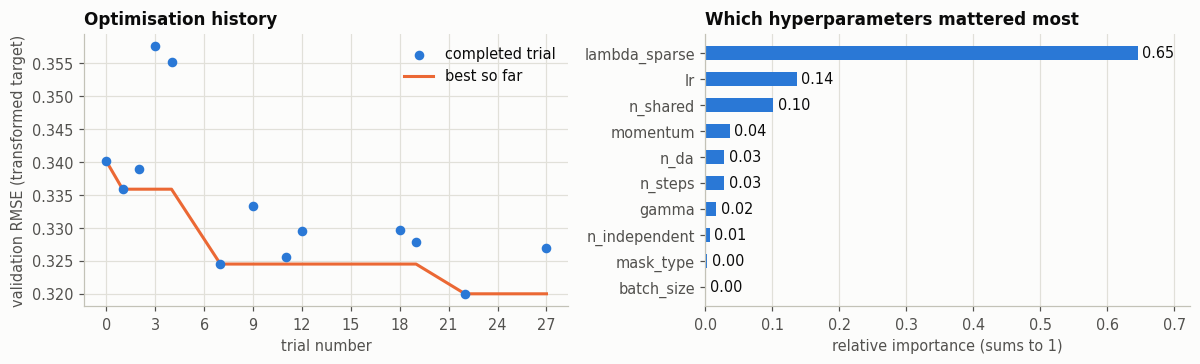

In [ ]:
done = trials_df[trials_df["state"] == "COMPLETE"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# Left: the score of each completed trial, and the best score found so far.
axes[0].scatter(done["number"], done["val_rmse"], s=28, color=BLUE, label="completed trial", zorder=3)
axes[0].plot(done["number"], done["val_rmse"].cummin(), color=ORANGE, label="best so far")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))     # trial numbers are whole numbers
axes[0].set_xlabel("trial number")
axes[0].set_ylabel("validation RMSE (transformed target)")
axes[0].set_title("Optimisation history")
axes[0].legend()

# Right: how much each hyperparameter explains the differences between trials.
if n_complete >= 2:
    importance = optuna.importance.get_param_importances(study)
    imp = pd.Series(importance).sort_values()
    bars = axes[1].barh(imp.index, imp.values, color=BLUE, height=0.55)
    axes[1].bar_label(bars, labels=[f"{v:.2f}" for v in imp.values], padding=3, color=INK)
    axes[1].set_xlabel("relative importance (sums to 1)")
    axes[1].set_title("Which hyperparameters mattered most")
    axes[1].grid(axis="y", visible=False)
    axes[1].margins(x=0.12)
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** on the left, each dot is one completed trial; the line shows the best score found up to that point, so a line that has gone flat means further trials stopped helping. On the right, a long bar means the validation score changed a lot when that hyperparameter changed; a short bar means the model was not sensitive to it within the range searched.

## 9. 5-fold cross-validation

A single validation split can be lucky or unlucky. **k-fold cross-validation** gives a more reliable estimate: the training+validation rows are cut into 5 folds, and the model is trained 5 times, each time holding out a different fold for scoring. The result is reported as mean ± standard deviation over the 5 folds.

Two details:

* The folds are **grouped by house `id`** (`GroupKFold`), for the same reason as the main split.
* Early stopping needs data to watch. Inside each fold, 10% of that fold's training rows are set aside for it, so the fold being scored is never used for any decision.

The default and the tuned hyperparameters are both cross-validated. The test set is still not used.

In [ ]:
def cross_validate(fs, cfg, params, label):
    """Run k-fold cross-validation for one configuration.

    fs     - feature-set dict
    cfg    - variety settings (log_target, use_groups)
    params - hyperparameters to use
    label  - name used in the printed output and results table

    Returns a DataFrame with one row of metrics per fold.
    """
    if GROUP_SPLIT:
        folds = GroupKFold(n_splits=N_FOLDS).split(idx_trainval, groups=groups[idx_trainval])
    else:
        folds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(idx_trainval)

    rows = []
    for fold, (tr_rel, va_rel) in enumerate(folds, start=1):
        fold_train, fold_score = idx_trainval[tr_rel], idx_trainval[va_rel]
        # Carve 10% off the fold's training rows for early stopping; fold_score stays clean.
        fit_idx, stop_idx = split_once(fold_train, 0.10, SEED + fold)

        fit = fit_tabnet(fs, fit_idx, stop_idx, params=params,
                         log_target=cfg["log_target"], use_groups=cfg["use_groups"])
        m = evaluate(y_all[fold_score], fit.predict_dollars(fs["X"][fold_score]))
        rows.append(dict(fold=fold, **m))
        print(f"{label} | fold {fold}: RMSE {dollars(m['RMSE'])}, R2 {m['R2']:.4f}, MAPE {m['MAPE']:.2f}%")
    return pd.DataFrame(rows).set_index("fold")


cv_default = cross_validate(best_fs, best_cfg, DEFAULT_PARAMS, "default")
cv_tuned = cross_validate(best_fs, best_cfg, tuned_params, "tuned  ")

default | fold 1: RMSE $152,551, R2 0.8525, MAPE 13.29%
default | fold 2: RMSE $123,040, R2 0.8879, MAPE 12.39%
default | fold 3: RMSE $121,721, R2 0.8681, MAPE 13.60%
default | fold 4: RMSE $130,427, R2 0.8519, MAPE 12.87%
default | fold 5: RMSE $127,029, R2 0.8787, MAPE 13.02%
tuned   | fold 1: RMSE $156,213, R2 0.8453, MAPE 12.78%
tuned   | fold 2: RMSE $131,482, R2 0.8720, MAPE 12.67%
tuned   | fold 3: RMSE $127,801, R2 0.8546, MAPE 12.90%
tuned   | fold 4: RMSE $115,317, R2 0.8843, MAPE 12.52%
tuned   | fold 5: RMSE $125,446, R2 0.8817, MAPE 13.12%


In [ ]:
# Mean and standard deviation over the folds, for both configurations.
cv_summary = pd.concat({"default": cv_default.agg(["mean", "std"]).T,
                        "tuned": cv_tuned.agg(["mean", "std"]).T}, axis=1)
display(cv_summary.style.format("{:,.4f}"))

for label, cv in [("default", cv_default), ("tuned", cv_tuned)]:
    results.append(dict(stage="cv", model=f"TabNet {label} ({best_variant.split()[0]})",
                        evaluated_on=f"{N_FOLDS}-fold CV mean", **cv.mean().to_dict()))
    results.append(dict(stage="cv", model=f"TabNet {label} ({best_variant.split()[0]})",
                        evaluated_on=f"{N_FOLDS}-fold CV std", **cv.std().to_dict()))

# The configuration with the better cross-validated score becomes the final model.
# Cross-validation is the fairer judge here: the tuned values were chosen on the single
# validation split, so they could simply be over-fitted to that split.
if cv_tuned[SELECT_METRIC].mean() < cv_default[SELECT_METRIC].mean():
    final_label, final_params = "tuned", {**DEFAULT_PARAMS, **tuned_params}
else:
    final_label, final_params = "default", dict(DEFAULT_PARAMS)
print(f"Final configuration: {final_label} hyperparameters "
      f"(CV {SELECT_METRIC}: default {dollars(cv_default[SELECT_METRIC].mean())}, "
      f"tuned {dollars(cv_tuned[SELECT_METRIC].mean())})")

Final configuration: default hyperparameters (CV RMSE: default $130,954, tuned $131,252)


**Interpretation:** `mean` is the average score over the 5 folds and `std` is how much it varied from fold to fold. A small `std` means the model's performance does not depend much on which rows it happened to be trained on. The configuration with the lower mean RMSE is carried forward.

## 10. Final model and test-set evaluation

The chosen configuration is trained once more on the training rows (with the validation rows for early stopping), and then scored on the **test set, which has not been used for anything so far**. This is the number to report and to use for the group's model comparisons.

In [ ]:
final = fit_tabnet(best_fs, idx_train, idx_val, params=final_params,
                   log_target=best_cfg["log_target"], use_groups=best_cfg["use_groups"])
final_model = final.model                                   # the network itself, used for interpretability below

X_test = best_fs["X"][idx_test]                             # unscaled test features
test_pred = final.predict_dollars(X_test)                   # the pipeline scales them, predicts, and returns dollars
test_metrics = evaluate(y_test, test_pred)

final_name = f"TabNet final ({best_variant.split()[0]}, {final_label})"
results.append(dict(stage="test", model=final_name, evaluated_on="test",
                    best_epoch=final_model.best_epoch, **test_metrics))

# Ridge on the same test rows, for reference.
ridge_test = evaluate(y_test, tt_ridge.inverse(ridge.predict(X_onehot[idx_test])))
results.append(dict(stage="test", model="Ridge (log target)", evaluated_on="test", **ridge_test))

test_df = pd.DataFrame([test_metrics, ridge_test], index=[final_name, "Ridge (log target)"])
display(test_df.style.format(METRIC_FORMAT))

,MAE,MAPE,RMSE,R2
"TabNet final (V2, default)","$68,962",12.39%,"$126,167",0.8947
Ridge (log target),"$74,840",13.27%,"$136,687",0.8764


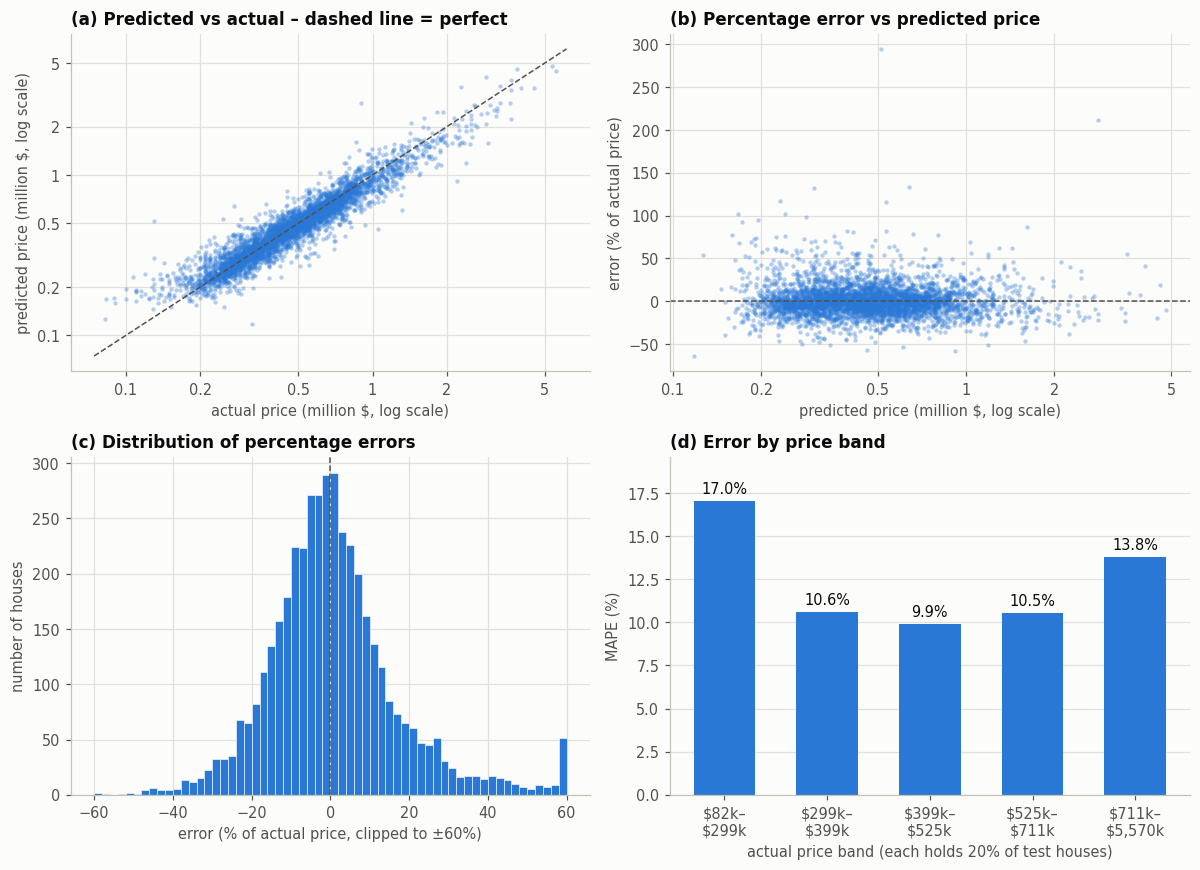

55.4% of test predictions are within 10% of the true price, 81.7% within 20%.
median percentage error: -0.61% (positive = predictions tend to be too high)


In [ ]:
residual = test_pred - y_test                    # positive = the model predicted too high
pct_error = residual / y_test * 100              # the same error as a % of the true price

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (a) Predicted vs actual. Points on the diagonal are perfect predictions.
ax = axes[0, 0]
ax.scatter(y_test / 1e6, test_pred / 1e6, s=8, alpha=0.35, color=BLUE, linewidths=0)
lims = [y_test.min() / 1e6 * 0.9, y_test.max() / 1e6 * 1.1]
ax.plot(lims, lims, color=INK_SOFT, linewidth=1, linestyle="--")
ax.set_xscale("log"); ax.set_yscale("log")       # log axes so cheap and expensive houses are both visible
price_log_axis(ax.xaxis); price_log_axis(ax.yaxis)
ax.set_xlabel("actual price (million $, log scale)")
ax.set_ylabel("predicted price (million $, log scale)")
ax.set_title("(a) Predicted vs actual – dashed line = perfect")

# (b) Percentage error against predicted price. A good model shows a flat band around 0.
ax = axes[0, 1]
ax.scatter(test_pred / 1e6, pct_error, s=8, alpha=0.35, color=BLUE, linewidths=0)
ax.axhline(0, color=INK_SOFT, linewidth=1, linestyle="--")
ax.set_xscale("log")
price_log_axis(ax.xaxis)
ax.set_xlabel("predicted price (million $, log scale)")
ax.set_ylabel("error (% of actual price)")
ax.set_title("(b) Percentage error vs predicted price")

# (c) Distribution of percentage errors.
ax = axes[1, 0]
ax.hist(np.clip(pct_error, -60, 60), bins=60, color=BLUE, edgecolor="#fcfcfb", linewidth=0.4)
ax.axvline(0, color=INK_SOFT, linewidth=1, linestyle="--")
ax.set_xlabel("error (% of actual price, clipped to ±60%)")
ax.set_ylabel("number of houses")
ax.set_title("(c) Distribution of percentage errors")

# (d) MAPE in five equal-sized price bands, cheapest to most expensive.
bands = pd.qcut(y_test, 5)
band_mape = pd.Series(np.abs(pct_error)).groupby(bands.codes).mean()
band_labels = [f"${iv.left/1000:,.0f}k–\n${iv.right/1000:,.0f}k" for iv in bands.categories]
ax = axes[1, 1]
bars = ax.bar(band_labels, band_mape.values, color=BLUE, width=0.6)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in band_mape.values], padding=3, color=INK)
ax.set_xlabel("actual price band (each holds 20% of test houses)")
ax.set_ylabel("MAPE (%)")
ax.set_title("(d) Error by price band")
ax.grid(axis="x", visible=False)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

within_10 = float((np.abs(pct_error) <= 10).mean() * 100)
within_20 = float((np.abs(pct_error) <= 20).mean() * 100)
print(f"{within_10:.1f}% of test predictions are within 10% of the true price, {within_20:.1f}% within 20%.")
print(f"median percentage error: {np.median(pct_error):+.2f}% (positive = predictions tend to be too high)")

**Interpretation:**

**(a)** the closer the cloud hugs the dashed diagonal, the better; points above it are over-predictions.

**(b)** a level band centred on 0 means the error does not depend on the price; a tilt would mean the model is biased for cheap or expensive houses.

**(c)** should be a narrow hump centred on 0.

**(d)** shows whether some price ranges are predicted worse than others. Relevant to fairness, since a model that is less accurate for cheap houses affects lower-income buyers more.

## 11. Interpretability

TabNet's attention masks record how much each feature was used. Two views:

* **Global feature importance** – averaged over all training rows: which features does the model rely on overall?
* **Per-row masks** – for individual houses, which features did each decision step look at?

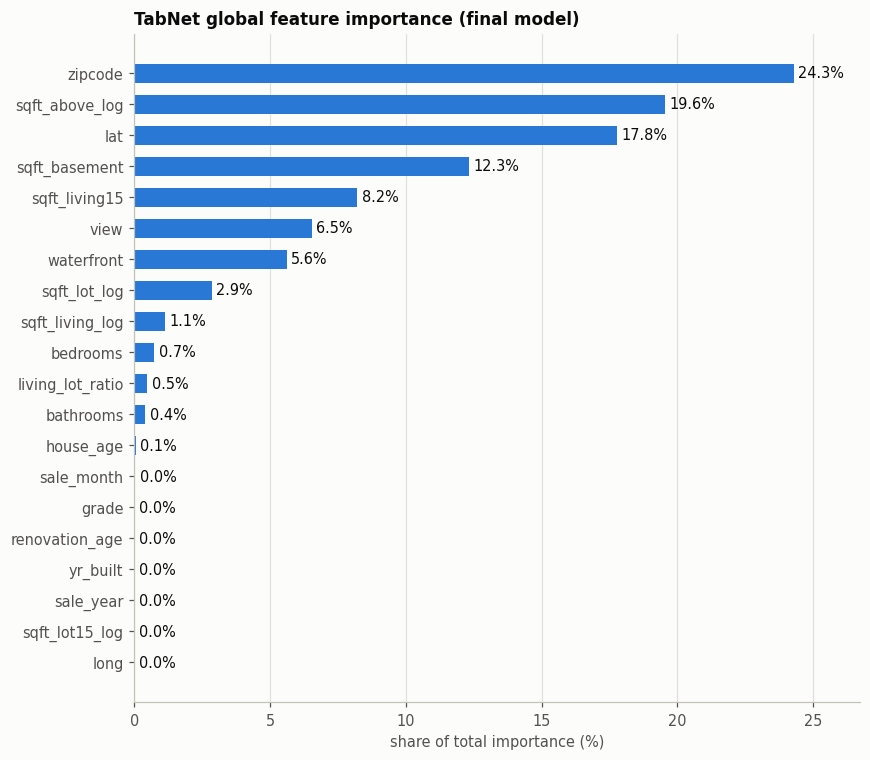

In [ ]:
def collapse_zipcode(values, fs):
    """If zipcode is spread over 70 one-hot columns, add them up into a single 'zipcode' entry.

    values - array whose LAST axis is 'one entry per feature column'
    Returns (values_with_zipcode_collapsed, feature_names).
    """
    if not fs["zip_positions"]:                       # zipcode is already a single column
        return values, fs["feature_names"]
    keep = [i for i in range(values.shape[-1]) if i not in set(fs["zip_positions"])]
    zip_total = values[..., fs["zip_positions"]].sum(axis=-1, keepdims=True)
    names = [fs["feature_names"][i] for i in keep] + ["zipcode"]
    return np.concatenate([values[..., keep], zip_total], axis=-1), names


# feature_importances_ has one value per input column and sums to 1.
importance, imp_names = collapse_zipcode(final_model.feature_importances_, best_fs)
imp = pd.Series(importance, index=imp_names).sort_values().tail(20)     # the 20 most important

fig, ax = plt.subplots(figsize=(8, 0.3 * len(imp) + 1))
bars = ax.barh(imp.index, imp.values * 100, color=BLUE, height=0.6)
ax.bar_label(bars, labels=[f"{v*100:.1f}%" for v in imp.values], padding=3, color=INK)
ax.set_xlabel("share of total importance (%)")
ax.set_title("TabNet global feature importance (final model)")
ax.grid(axis="y", visible=False)
ax.margins(x=0.1)
plt.tight_layout()
plt.show()

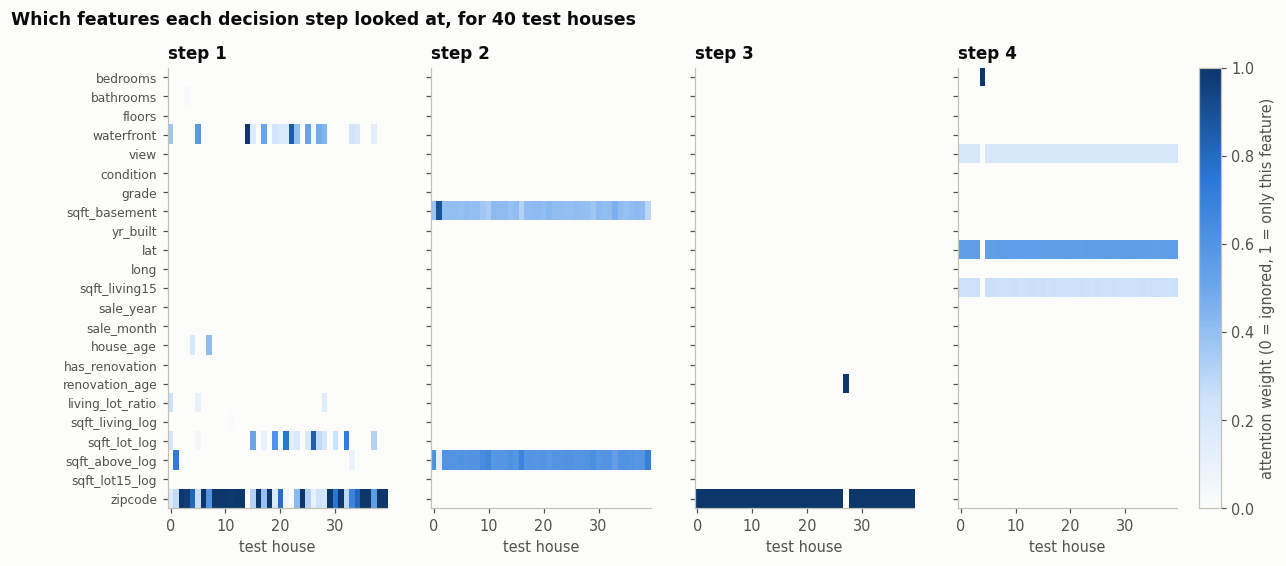

In [ ]:
# explain() returns, for each row, the mask of every decision step:
#   masks[step] has shape (n_rows, n_features); each row sums to 1 across the features.
n_show = 40                                           # number of test houses to display
_, masks = final_model.explain(final.scaler.transform(X_test[:n_show]))   # the network needs scaled inputs

n_steps = len(masks)
fig, axes = plt.subplots(1, n_steps, figsize=(3.1 * n_steps, 5.2), sharey=True, squeeze=False)
for step, ax in enumerate(axes[0]):
    mask, mask_names = collapse_zipcode(masks[step], best_fs)
    # Rows = features, columns = houses. Darker = that step paid more attention to that feature.
    im = ax.imshow(mask.T, aspect="auto", cmap=SEQ_CMAP, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"step {step + 1}")
    ax.set_xlabel("test house")
    ax.set_yticks(range(len(mask_names)))
    ax.set_yticklabels(mask_names, fontsize=8)
    ax.grid(False)

fig.colorbar(im, ax=axes[0].tolist(), fraction=0.025, pad=0.02, label="attention weight (0 = ignored, 1 = only this feature)")
fig.suptitle(f"Which features each decision step looked at, for {n_show} test houses", x=0.01, ha="left", fontweight="bold")
plt.show()

**Interpretation:** the bar chart ranks features by how much attention they received in total. In the heatmaps, each column is one house and each row is one feature; a dark cell means that decision step relied heavily on that feature for that house. Horizontal dark stripes are features a step uses for *every* house; scattered dark cells are features used only for *some* houses – that is TabNet's row-by-row feature selection at work.

## 12. Save the model and the results

Saved so the results can be handed to the group and the model can be reloaded without retraining:

* `models/tabnet_best.zip` – the trained network.
* `models/tabnet_best_meta.json` – everything else needed to use it: the feature order, the input-scaler and target-transform numbers, and the hyperparameters.
* `results/tabnet_results.csv` – every score from this notebook (baselines, varieties, cross-validation, test).
* `results/tabnet_optuna_trials.csv` – every tuning trial (written in Section 8).

In [ ]:
# save_model adds the ".zip" extension itself and returns the full path.
model_path = final_model.save_model(str(MODELS_DIR / "tabnet_best"))

meta = dict(
    variant=best_variant,
    feature_set=best_cfg["fs"],
    feature_names=best_fs["feature_names"],
    zipcode_categories=[int(c.split("_")[1]) for c in ZIP_COLS],   # position in this list = integer zipcode code
    # The two fitted pre-processing steps, so the pipeline can be rebuilt without retraining.
    input_scaler=dict(columns=[best_fs["feature_names"][i] for i in final.scaler.positions],
                      mean=final.scaler.mean_.tolist(), std=final.scaler.std_.tolist()),
    target_transform=dict(log=final.tt.log, mean=final.tt.mean_, std=final.tt.std_,
                          clip_min=final.tt.min_ - 1.0, clip_max=final.tt.max_ + 1.0),
    hyperparameters=final_params,
    hyperparameter_source=final_label,
    best_epoch=int(final_model.best_epoch),
    test_metrics=test_metrics,
    split=dict(group_split=GROUP_SPLIT, seed=SEED, test_size=TEST_SIZE, val_size=VAL_SIZE),
    fast_run=FAST_RUN,
)
(MODELS_DIR / "tabnet_best_meta.json").write_text(json.dumps(meta, indent=2))

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_DIR / "tabnet_results.csv", index=False)

# Reload the saved model and confirm it gives the same predictions as the one in memory.
reloaded = TabNetRegressor()
reloaded.load_model(model_path)
X_test_scaled = final.scaler.transform(X_test)
assert np.allclose(reloaded.predict(X_test_scaled), final_model.predict(X_test_scaled), atol=1e-4), "Reloaded model differs"

print(f"saved {model_path}")
print(f"saved {MODELS_DIR / 'tabnet_best_meta.json'}")
print(f"saved {RESULTS_DIR / 'tabnet_results.csv'} ({len(results_df)} rows)")
print("Reloaded model reproduces the test predictions.")

Successfully saved model at models/tabnet_best.zip
saved models/tabnet_best.zip
saved models/tabnet_best_meta.json
saved results/tabnet_results.csv (15 rows)
Reloaded model reproduces the test predictions.


### Download the saved files

On Google Colab the `models/` and `results/` folders live on a temporary disk that is wiped when the session ends. The buttons below pack each folder into a zip file and download it.

What each zip contains:

* **`models.zip`** – everything needed to reuse the trained model without retraining:
  * `tabnet_best.zip` – the trained network (leave this inner zip as it is; TabNet loads it directly with `load_model`).
  * `tabnet_best_meta.json` – the feature order, the input-scaler and target-transform numbers, the hyperparameters and the test scores.
* **`results.zip`** – the scores, for the group's model comparison:
  * `tabnet_results.csv` – every score from this notebook (baselines, varieties, cross-validation, test).
  * `tabnet_optuna_trials.csv` – every tuning trial from Section 8.

In [ ]:
import shutil
import ipywidgets as widgets

IN_COLAB = "google.colab" in sys.modules      # True only when running on Google Colab
download_note = widgets.Output()              # area under the buttons for messages


def make_download_button(folder):
    """Return a button that zips `folder` and downloads the zip when it is pressed."""
    button = widgets.Button(description=f"Download {folder.name}.zip", icon="download",
                            layout=widgets.Layout(width="220px"))

    def on_click(_):
        # Zip at the moment of the click, so the zip always holds the latest files.
        zip_path = shutil.make_archive(folder.name, "zip", root_dir=folder)   # e.g. models.zip
        if IN_COLAB:
            from google.colab import files
            files.download(zip_path)          # hands the file to the browser as a download
        else:
            # Outside Colab there is no browser download helper, so just say where the zip is.
            with download_note:
                print(f"saved {Path(zip_path).resolve()}")

    button.on_click(on_click)
    return button


display(widgets.HBox([make_download_button(MODELS_DIR), make_download_button(RESULTS_DIR)]), download_note)

Output()

## 13. Conclusions

The next cell writes a summary from the numbers computed above.

In [ ]:
run = "FAST_RUN smoke test (numbers not meaningful)" if FAST_RUN else "full run"
pct = lambda x: f"{x:.2f}%" if pd.notna(x) else "n/a"

# Varieties on validation, best first, with Ridge for reference
v = pd.DataFrame([r for r in results if r["stage"] == "variant"]).set_index("model")
ridge_val = next(r for r in results if r["model"] == "Ridge (log target)" and r["evaluated_on"] == "validation")
val = v[["RMSE", "R2", "MAPE"]].copy()
val.loc["Ridge baseline"] = [ridge_val["RMSE"], ridge_val["R2"], ridge_val.get("MAPE", np.nan)]
val = val.sort_values("RMSE")
val_tbl = pd.DataFrame({
    "RMSE": val["RMSE"].map(dollars),
    "R²": val["R2"].map("{:.4f}".format),
    "MAPE": val["MAPE"].map(pct),
}, index=val.index.rename("Variety"))

# Cross-validation, default vs tuned
cv_tbl = pd.DataFrame({
    "RMSE": [f"{dollars(d['RMSE'].mean())} ± {dollars(d['RMSE'].std())}" for d in (cv_default, cv_tuned)],
    "R²": [f"{d['R2'].mean():.4f} ± {d['R2'].std():.4f}" for d in (cv_default, cv_tuned)],
    "MAPE": [pct(d["MAPE"].mean()) for d in (cv_default, cv_tuned)],
}, index=pd.Index(["Default", "Tuned"], name="Hyperparameters"))

# Held-out test set
test_tbl = pd.DataFrame({
    "MAE": [dollars(m["MAE"]) for m in (test_metrics, ridge_test)],
    "RMSE": [dollars(m["RMSE"]) for m in (test_metrics, ridge_test)],
    "R²": [f"{m['R2']:.4f}" for m in (test_metrics, ridge_test)],
    "MAPE": [pct(m["MAPE"]) for m in (test_metrics, ridge_test)],
}, index=pd.Index(["Final model", "Ridge"], name="Model"))

md = "\n\n".join([
    f"**Run:** {run} | **Tuning:** {len(study.trials)} Optuna trials on *{best_variant}* | "
    f"**Carried forward:** {final_label} hyperparameters",
    "<br>\n\n### **Varieties (validation, default hyperparameters)**", val_tbl.to_markdown(),
    f"<br>\n\n### **{N_FOLDS}-fold cross-validation ({best_variant.split()[0]})**", cv_tbl.to_markdown(),
    "<br>\n\n### **Held-out test set**", test_tbl.to_markdown(),
    f"<br>\n\n{within_10:.1f}% of predictions within 10% of the true price; {within_20:.1f}% within 20%.",
])
display(Markdown(md.replace("$", r"\$")))

**Run:** full run | **Tuning:** 30 Optuna trials on *V2 one-hot, log target* | **Carried forward:** default hyperparameters

<br>

### **Varieties (validation, default hyperparameters)**

| Variety                       | RMSE     |     R² | MAPE   |
|:------------------------------|:---------|-------:|:-------|
| V6 pre-trained (V2 base)      | \$110,233 | 0.8969 | 12.64% |
| V2 one-hot, log target        | \$120,037 | 0.8778 | 12.36% |
| V5 raw rebuilt + emb, log     | \$120,792 | 0.8762 | 12.75% |
| V4 zip embedding, log         | \$120,792 | 0.8762 | 12.75% |
| V3 one-hot grouped, log       | \$122,635 | 0.8724 | 12.64% |
| Ridge baseline                | \$123,425 | 0.8708 | 13.32% |
| V7 no input scaling (V2 base) | \$129,343 | 0.8581 | 12.99% |
| V1 one-hot, raw target        | \$129,541 | 0.8576 | 15.43% |

<br>

### **5-fold cross-validation (V2)**

| Hyperparameters   | RMSE               | R²              | MAPE   |
|:------------------|:-------------------|:----------------|:-------|
| Default           | \$130,954 ± \$12,550 | 0.8678 ± 0.0159 | 13.03% |
| Tuned             | \$131,252 ± \$15,188 | 0.8676 ± 0.0170 | 12.80% |

<br>

### **Held-out test set**

| Model       | MAE     | RMSE     |     R² | MAPE   |
|:------------|:--------|:---------|-------:|:-------|
| Final model | \$68,962 | \$126,167 | 0.8947 | 12.39% |
| Ridge       | \$74,840 | \$136,687 | 0.8764 | 13.27% |

<br>

55.4% of predictions within 10% of the true price; 81.7% within 20%.

### Why these metrics and this validation method

* **Metrics.** This is a regression problem, so error is measured in dollars (MAE, RMSE), as a percentage (MAPE) and as explained variance (R²). MAE and MAPE describe the typical error; RMSE is more sensitive to the occasional very large miss; R² allows comparison with the other group members' models regardless of units. All four are computed after converting predictions back to dollars, so models trained on different target scales are compared fairly.
* **Validation.** Three levels are used, each for a different job: a validation split for early stopping and tuning, 5-fold cross-validation for a stable estimate with a spread, and a test set used once for the final figure. The test set is the group's shared test file; the train/validation split and the cross-validation folds are grouped by house `id`, so all sales of one house stay together.

### Limitations

* **Single runs.** Each variety and each Optuna trial is one training run with one seed. Small differences between varieties are within the noise that a different seed would produce.
* **Small data for a deep model.** About 21,600 rows is small for deep learning. Gradient-boosted trees typically do as well or better on tables of this size, and train in seconds.
* **One test split.** The final figure comes from a single 20% test file; a different split would give a slightly different number (the cross-validation `std` indicates by how much).
* **One year of sales.** The data covers May 2014 – May 2015 in one county. The model has not been tested on later years or other areas, and prices drift over time.
* **Outliers kept.** Extreme rows (for example a house listed with 33 bedrooms) are still in the data.
* **Location as a proxy.** Zipcode and latitude/longitude are strong predictors, but location correlates with income and demographics. A model used for lending or valuation could reinforce existing neighbourhood disparities; the error-by-price-band chart is a first check on this.

### Possible improvements

* More Optuna trials, and tuning with cross-validation rather than a single validation split.
* Average the predictions of several TabNet models trained with different seeds.
* Add features from the raw file that the processed file dropped, such as distance to the city centre or the exact sale date.